# Perceptron MNIST 

Single-layer perceptron for MNIST. 


Device: cpu
TRAIN_PATH: /kaggle/input/competitions/digit-recognizer/train.csv
TEST_PATH : /kaggle/input/competitions/digit-recognizer/test.csv
Train shape: (42000, 785)
Test shape : (28000, 784)
Perceptron(
  (fc): Linear(in_features=784, out_features=10, bias=True)
)
Saved figure: perceptron_architecture.png


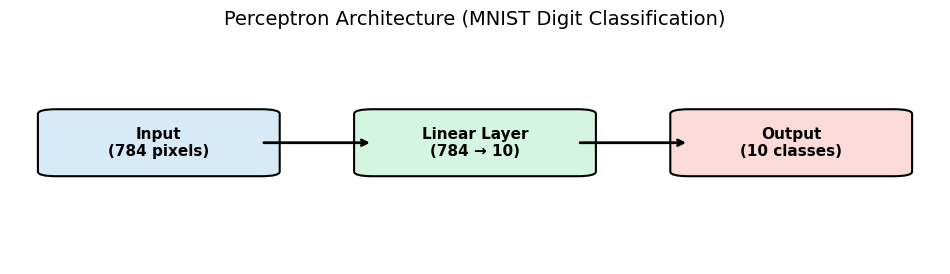

Trainable parameters: 7850

Perceptron Architecture

Input Layer: 784 features (28x28 image flattened)
↓
Linear Layer (784 → 10)
↓
Softmax via CrossEntropyLoss
↓
Output: Digit class (0-9)

Epoch 1/8 | Train Loss 0.7906 Acc 0.8287 | Val Loss 0.4636 Acc 0.8800
Epoch 2/8 | Train Loss 0.4045 Acc 0.8940 | Val Loss 0.3719 Acc 0.8960
Epoch 3/8 | Train Loss 0.3450 Acc 0.9068 | Val Loss 0.3369 Acc 0.9048
Epoch 4/8 | Train Loss 0.3173 Acc 0.9130 | Val Loss 0.3179 Acc 0.9090
Epoch 5/8 | Train Loss 0.3016 Acc 0.9166 | Val Loss 0.3044 Acc 0.9131
Epoch 6/8 | Train Loss 0.2898 Acc 0.9200 | Val Loss 0.2975 Acc 0.9145
Epoch 7/8 | Train Loss 0.2810 Acc 0.9220 | Val Loss 0.2908 Acc 0.9155
Epoch 8/8 | Train Loss 0.2738 Acc 0.9243 | Val Loss 0.2868 Acc 0.9176

Final Validation Accuracy: 0.9176190476190477
Final Validation F1 Score: 0.9167208511085339
Training Time: 11.895490169525146
Saved figure: perceptron_curves.png


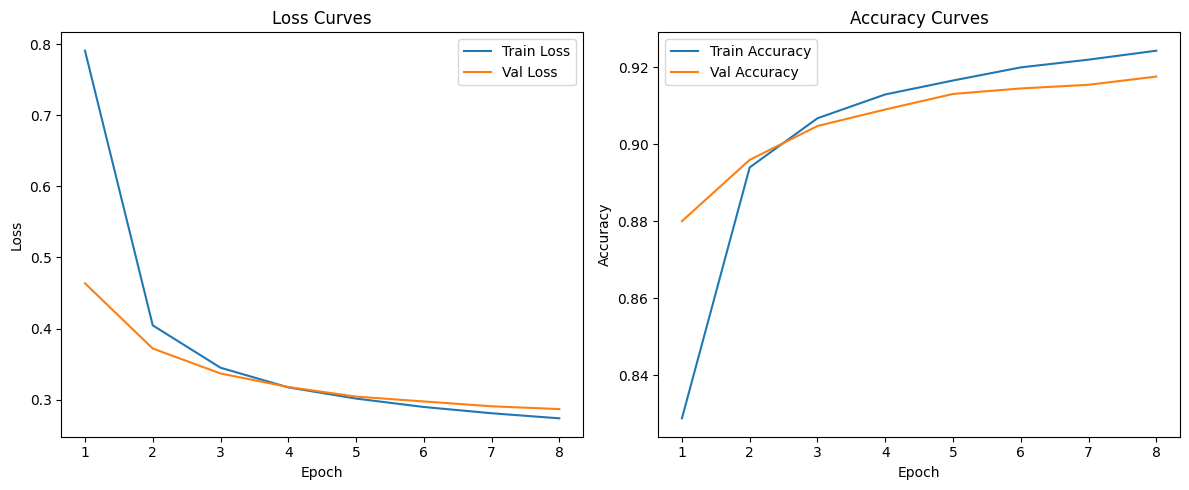

Saved figure: perceptron_confusion.png


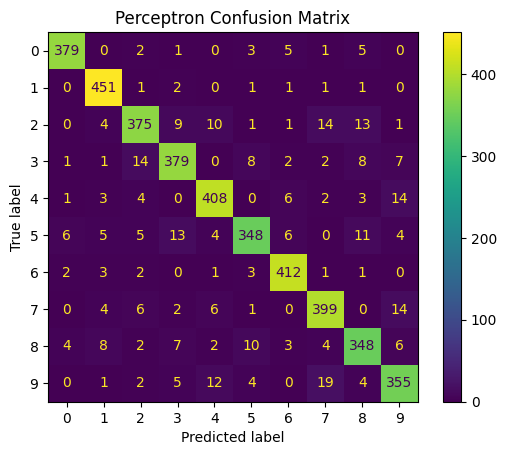

Saved figure: perceptron_weights.png


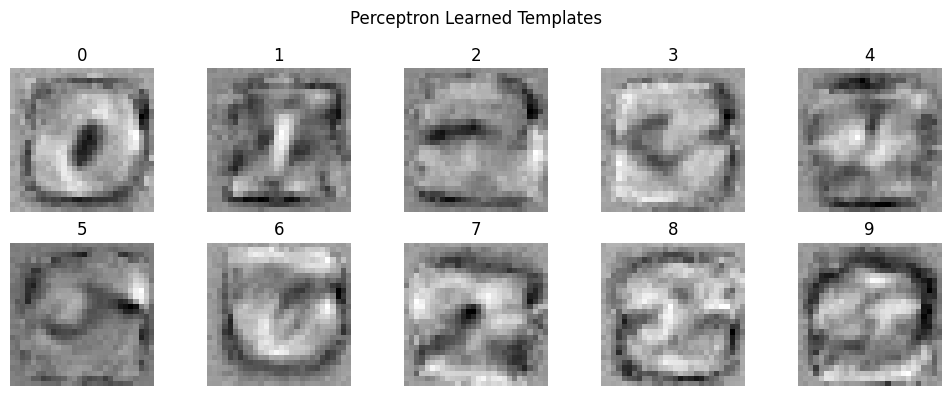

[Full Train] Epoch 1/8 Loss 0.7677
[Full Train] Epoch 2/8 Loss 0.3922
[Full Train] Epoch 3/8 Loss 0.3369
[Full Train] Epoch 4/8 Loss 0.3117
[Full Train] Epoch 5/8 Loss 0.2965
[Full Train] Epoch 6/8 Loss 0.2857
[Full Train] Epoch 7/8 Loss 0.2766
[Full Train] Epoch 8/8 Loss 0.2712
Saved submission_perceptron.csv
   ImageId  Label
0        1      2
1        2      0
2        3      9
3        4      7
4        5      3

Perceptron Results Summary
{'Model': 'Perceptron', 'Val Accuracy': np.float64(0.9176190476190477), 'Val F1': 0.9167208511085339, 'Train Time (s)': 11.895490169525146, 'Params': 7850, 'Kaggle Score': 0.0}
Saved metrics JSON: perceptron_results.json
Saved metrics CSV: perceptron_results.csv


In [1]:
# =========================
# Perceptron Notebook (Digit Recognizer)
# =========================

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Auto-save figures and metrics
# -----------------------------
from pathlib import Path
import json

OUTPUT_DIR = Path('.')
FIGURE_QUEUE = ['perceptron_architecture.png', 'perceptron_curves.png', 'perceptron_confusion.png', 'perceptron_weights.png'].copy()

_original_show = plt.show

def _json_safe(obj):
    try:
        import numpy as _np
        if isinstance(obj, (_np.integer, )):
            return int(obj)
        if isinstance(obj, (_np.floating, )):
            return float(obj)
        if isinstance(obj, _np.ndarray):
            return obj.tolist()
    except Exception:
        pass
    if isinstance(obj, Path):
        return str(obj)
    return obj


def _auto_save_show(*args, **kwargs):
    fig = plt.gcf()
    if FIGURE_QUEUE:
        fname = OUTPUT_DIR / FIGURE_QUEUE.pop(0)
        fig.savefig(fname, dpi=300, bbox_inches='tight')
        print(f'Saved figure: {fname}')
    return _original_show(*args, **kwargs)

plt.show = _auto_save_show


import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score

# -----------------------------
# Reproducibility
# -----------------------------
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# -----------------------------
# Find dataset automatically
# -----------------------------
def find_digit_recognizer_paths():
    base = "/kaggle/input"
    for root, _, files in os.walk(base):
        if "train.csv" in files and "test.csv" in files:
            return os.path.join(root, "train.csv"), os.path.join(root, "test.csv")
    raise FileNotFoundError("Digit Recognizer dataset not found")

TRAIN_PATH, TEST_PATH = find_digit_recognizer_paths()

print("TRAIN_PATH:", TRAIN_PATH)
print("TEST_PATH :", TEST_PATH)

# -----------------------------
# Load dataset
# -----------------------------
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

y_all = train_df["label"].values.astype(np.int64)
X_all = train_df.drop(columns=["label"]).values.astype(np.float32) / 255.0
X_test = test_df.values.astype(np.float32) / 255.0

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

# -----------------------------
# Dataset class
# -----------------------------
class MNISTDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = torch.tensor(self.X[idx], dtype=torch.float32)
        if self.y is None:
            return x
        y = torch.tensor(self.y[idx], dtype=torch.long)
        return x, y

# -----------------------------
# Train / Validation split
# -----------------------------
full_ds = MNISTDataset(X_all, y_all)

val_size = int(0.1 * len(full_ds))
train_size = len(full_ds) - val_size

generator = torch.Generator().manual_seed(SEED)
train_ds, val_ds = random_split(full_ds, [train_size, val_size], generator=generator)

BATCH_SIZE = 128

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

# -----------------------------
# Perceptron model
# -----------------------------
class Perceptron(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(784, 10)

    def forward(self, x):
        return self.fc(x)

model = Perceptron().to(device)
print(model)

# -----------------------------
# Perceptron Architecture Diagram
# -----------------------------
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(12, 3))

def draw_box(text, x, color):
    box = FancyBboxPatch(
        (x, 0.4), 0.22, 0.25,
        boxstyle="round,pad=0.02",
        linewidth=1.5,
        edgecolor="black",
        facecolor=color
    )
    ax.add_patch(box)
    ax.text(
        x + 0.11, 0.525, text,
        ha="center", va="center",
        fontsize=11, weight="bold"
    )

draw_box("Input\n(784 pixels)", 0.05, "#D6EAF8")
draw_box("Linear Layer\n(784 → 10)", 0.39, "#D5F5E3")
draw_box("Output\n(10 classes)", 0.73, "#FADBD8")

ax.annotate("", xy=(0.39, 0.525), xytext=(0.27, 0.525),
            arrowprops=dict(arrowstyle="->", linewidth=2))
ax.annotate("", xy=(0.73, 0.525), xytext=(0.61, 0.525),
            arrowprops=dict(arrowstyle="->", linewidth=2))

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title("Perceptron Architecture (MNIST Digit Classification)", fontsize=14)
ax.axis("off")
plt.show()

# -----------------------------
# Parameter count
# -----------------------------
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Trainable parameters:", count_params(model))

print("""
Perceptron Architecture

Input Layer: 784 features (28x28 image flattened)
↓
Linear Layer (784 → 10)
↓
Softmax via CrossEntropyLoss
↓
Output: Digit class (0-9)
""")

# -----------------------------
# Training Setup
# -----------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 8

# -----------------------------
# Evaluation function
# -----------------------------
def eval_acc_f1(model, loader):
    model.eval()

    all_preds = []
    all_true = []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            logits = model(x)
            preds = torch.argmax(logits, dim=1)

            all_preds.append(preds.cpu().numpy())
            all_true.append(y.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_true = np.concatenate(all_true)

    acc = (all_preds == all_true).mean()
    f1 = f1_score(all_true, all_preds, average="macro")

    return acc, f1, all_true, all_preds

# -----------------------------
# Training Loop
# -----------------------------
train_losses = []
val_losses = []

train_accs = []
val_accs = []

start = time.time()

for epoch in range(1, EPOCHS + 1):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        preds = torch.argmax(logits, dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    # Validation
    model.eval()

    val_loss = 0.0
    vcorrect = 0
    vtotal = 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)

            logits = model(x)
            loss = criterion(logits, y)

            val_loss += loss.item()

            preds = torch.argmax(logits, dim=1)
            vcorrect += (preds == y).sum().item()
            vtotal += y.size(0)

    val_loss /= len(val_loader)
    val_acc = vcorrect / vtotal

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"Epoch {epoch}/{EPOCHS} | "
        f"Train Loss {train_loss:.4f} Acc {train_acc:.4f} | "
        f"Val Loss {val_loss:.4f} Acc {val_acc:.4f}"
    )

train_time = time.time() - start

# -----------------------------
# Final Evaluation
# -----------------------------
final_acc, final_f1, y_true, y_pred = eval_acc_f1(model, val_loader)

print("\nFinal Validation Accuracy:", final_acc)
print("Final Validation F1 Score:", final_f1)
print("Training Time:", train_time)

# -----------------------------
# Training Curves
# -----------------------------
epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Val Loss")
plt.legend()
plt.title("Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accs, label="Train Accuracy")
plt.plot(epochs, val_accs, label="Val Accuracy")
plt.legend()
plt.title("Accuracy Curves")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()

# -----------------------------
# Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot(values_format="d")
plt.title("Perceptron Confusion Matrix")
plt.show()

# -----------------------------
# Visualize learned weights
# -----------------------------
W = model.fc.weight.detach().cpu().numpy().reshape(10, 28, 28)

plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(W[i], cmap="gray")
    plt.title(str(i))
    plt.axis("off")

plt.suptitle("Perceptron Learned Templates")
plt.tight_layout()
plt.show()

# -----------------------------
# Train on full dataset
# -----------------------------
full_loader = DataLoader(MNISTDataset(X_all, y_all), batch_size=BATCH_SIZE, shuffle=True)

# Reinitialize model for full training
model = Perceptron().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(1, EPOCHS + 1):
    model.train()
    running = 0.0

    for x, y in full_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        running += loss.item()

    print(f"[Full Train] Epoch {epoch}/{EPOCHS} Loss {running / len(full_loader):.4f}")

# -----------------------------
# Kaggle Submission
# -----------------------------
test_loader = DataLoader(MNISTDataset(X_test), batch_size=BATCH_SIZE, shuffle=False)

model.eval()
preds_all = []

with torch.no_grad():
    for x in test_loader:
        x = x.to(device)
        preds = torch.argmax(model(x), dim=1)
        preds_all.append(preds.cpu().numpy())

preds_all = np.concatenate(preds_all)

submission = pd.DataFrame({
    "ImageId": np.arange(1, len(preds_all) + 1),
    "Label": preds_all
})

submission.to_csv("submission_perceptron.csv", index=False)

print("Saved submission_perceptron.csv")
print(submission.head())

# -----------------------------
# Save results for comparison
# -----------------------------
perceptron_results = {
    "Model": "Perceptron",
    "Val Accuracy": final_acc,
    "Val F1": final_f1,
    "Train Time (s)": train_time,
    "Params": count_params(model),
    "Kaggle Score": 0.0
}

print("\nPerceptron Results Summary")
print(perceptron_results)


# -----------------------------
# Export metrics for report
# -----------------------------
try:
    _results = perceptron_results
    import pandas as pd
    _results_path_json = OUTPUT_DIR / 'perceptron_results.json'
    _results_path_csv = OUTPUT_DIR / 'perceptron_results.csv'
    with open(_results_path_json, 'w') as f:
        json.dump({k: _json_safe(v) for k, v in _results.items()}, f, indent=2)
    pd.DataFrame([{k: _json_safe(v) for k, v in _results.items()}]).to_csv(_results_path_csv, index=False)
    print(f'Saved metrics JSON: {_results_path_json}')
    print(f'Saved metrics CSV: {_results_path_csv}')
except Exception as exc:
    print('Could not export metrics automatically:', exc)
